In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = os.path.join("..","datasets","raw","Telco-Customer-Churn.csv")

In [3]:
telco = pd.read_csv(DATA_PATH)
print(len(telco))
telco.head().T

7043


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# TotalCharges - converting dtype to numeric
telco.TotalCharges = pd.to_numeric(telco.TotalCharges, errors='coerce')
telco.TotalCharges = telco.TotalCharges.fillna(0)

In [6]:
# Normalizing column names
telco.columns = telco.columns.str.lower().str.replace(' ','_')
# list of categorical columns
string_columns = list(telco.dtypes[telco.dtypes=='object'].index)
# Normalizing categorical values
for col in string_columns:
    telco[col] = telco[col].str.lower().str.replace(' ','_')
    
# Target Variable - Converting dtype no numeric - binary
telco.churn = (telco.churn=='yes').astype('int')

In [7]:
# Train, Validation and Test set
df_train_full, df_test = train_test_split(telco, test_size=0.2, random_state=12)
df_train, df_val = train_test_split(df_train_full, test_size=0.33, random_state=3)

y_train = df_train.churn.values
y_val = df_val.churn.values

del df_train['churn']
del df_val['churn']

## Exploratory Data Analysis

In [8]:
churn = df_train_full.churn.value_counts()
churn

0    4131
1    1503
Name: churn, dtype: int64

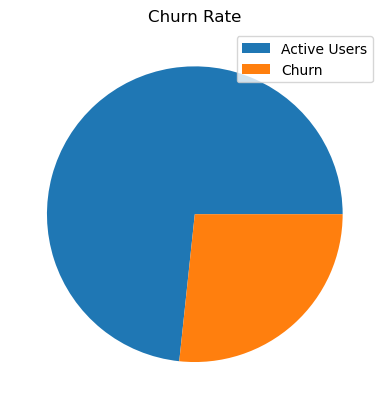

In [9]:
plt.pie(churn)
plt.title("Churn Rate")
plt.legend(['Active Users', 'Churn'])
plt.show()

In [10]:
global_mean = df_train_full.churn.mean()
print("Global Mean: {}".format(round(global_mean,3)))

Global Mean: 0.267


In [11]:
numerical = ["tenure", "monthlycharges", "totalcharges"]
categorical = ["gender", "partner", "dependents", "phoneservice", "multiplelines", "internetservice",
"onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies", "contract",
"paperlessbilling", "paymentmethod"]

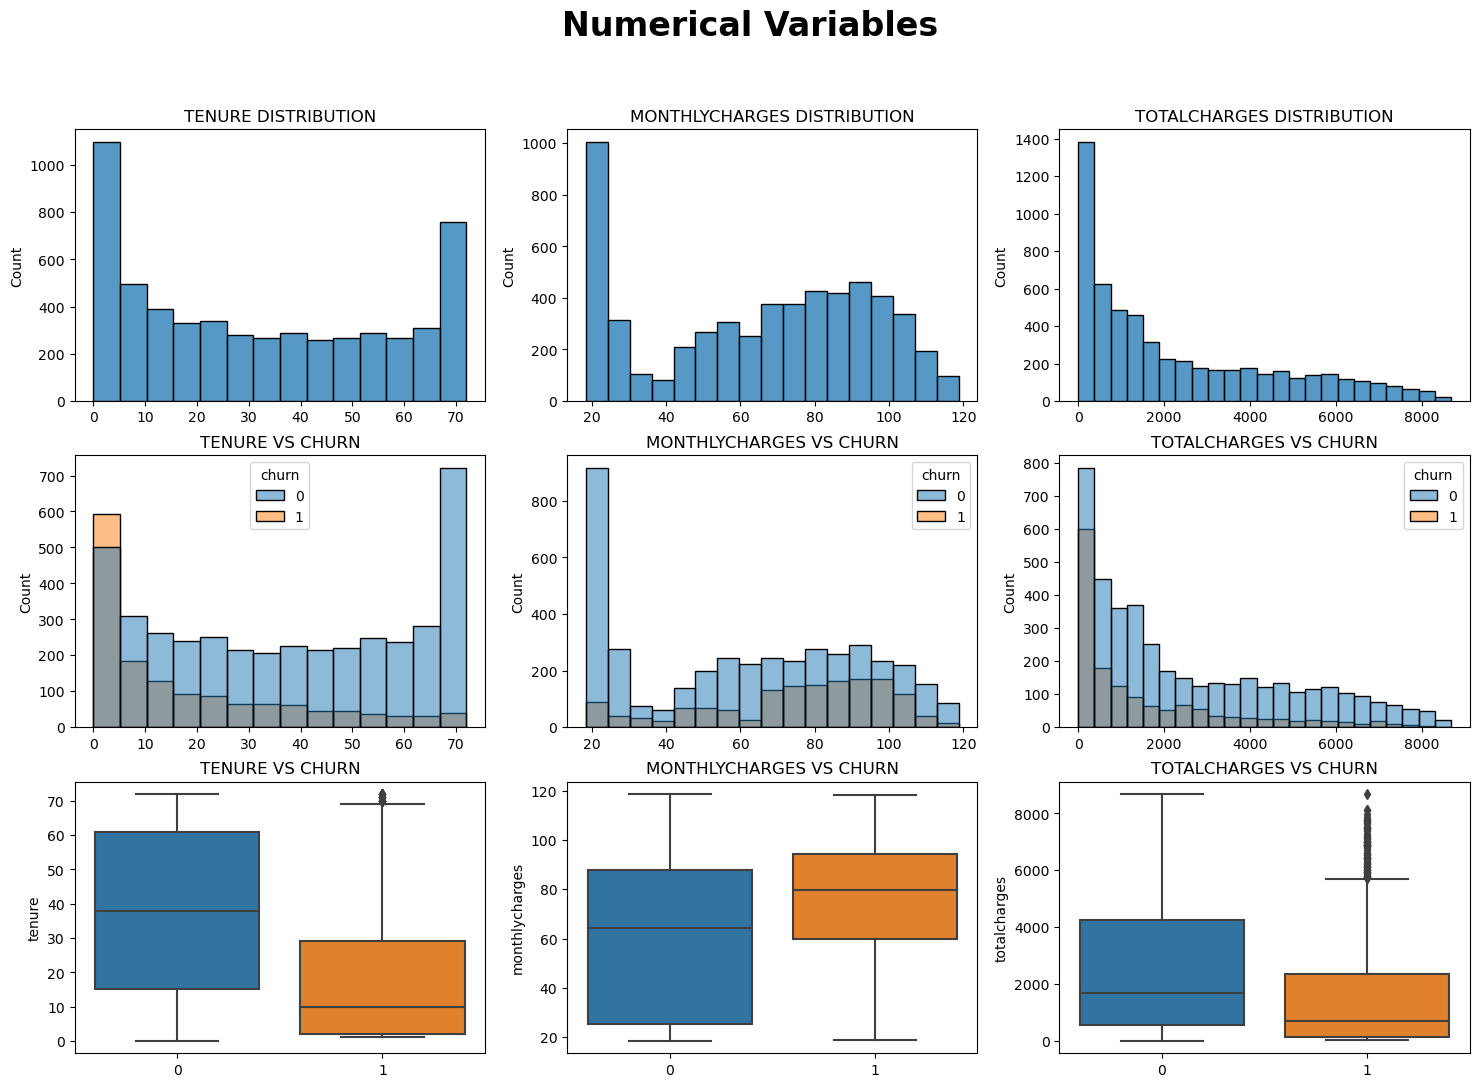

In [39]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(18,12))
ax = ax.flatten()
plt.suptitle('Numerical Variables', fontweight='bold', fontsize=24)

for idx, var in enumerate(numerical):
    # Distribution Plots
    sns.histplot(x=var,data=df_train_full, ax=ax[idx])
    ax[idx].set_title((var + ' distribution').upper())
    ax[idx].set_xlabel(None)
    
    # vs Churn --- Histograms
    sns.histplot(x=var,data=df_train_full, hue='churn', ax=ax[idx+3])
    ax[idx+3].set_title((var + ' vs Churn').upper())
    ax[idx+3].set_xlabel(None)
    
    # vs Churn --- Boxplots
    sns.boxplot(y=var, data=df_train_full, x='churn', ax=ax[idx+6])
    ax[idx+6].set_title((var + ' vs Churn').upper())
    ax[idx+6].set_xlabel(None)

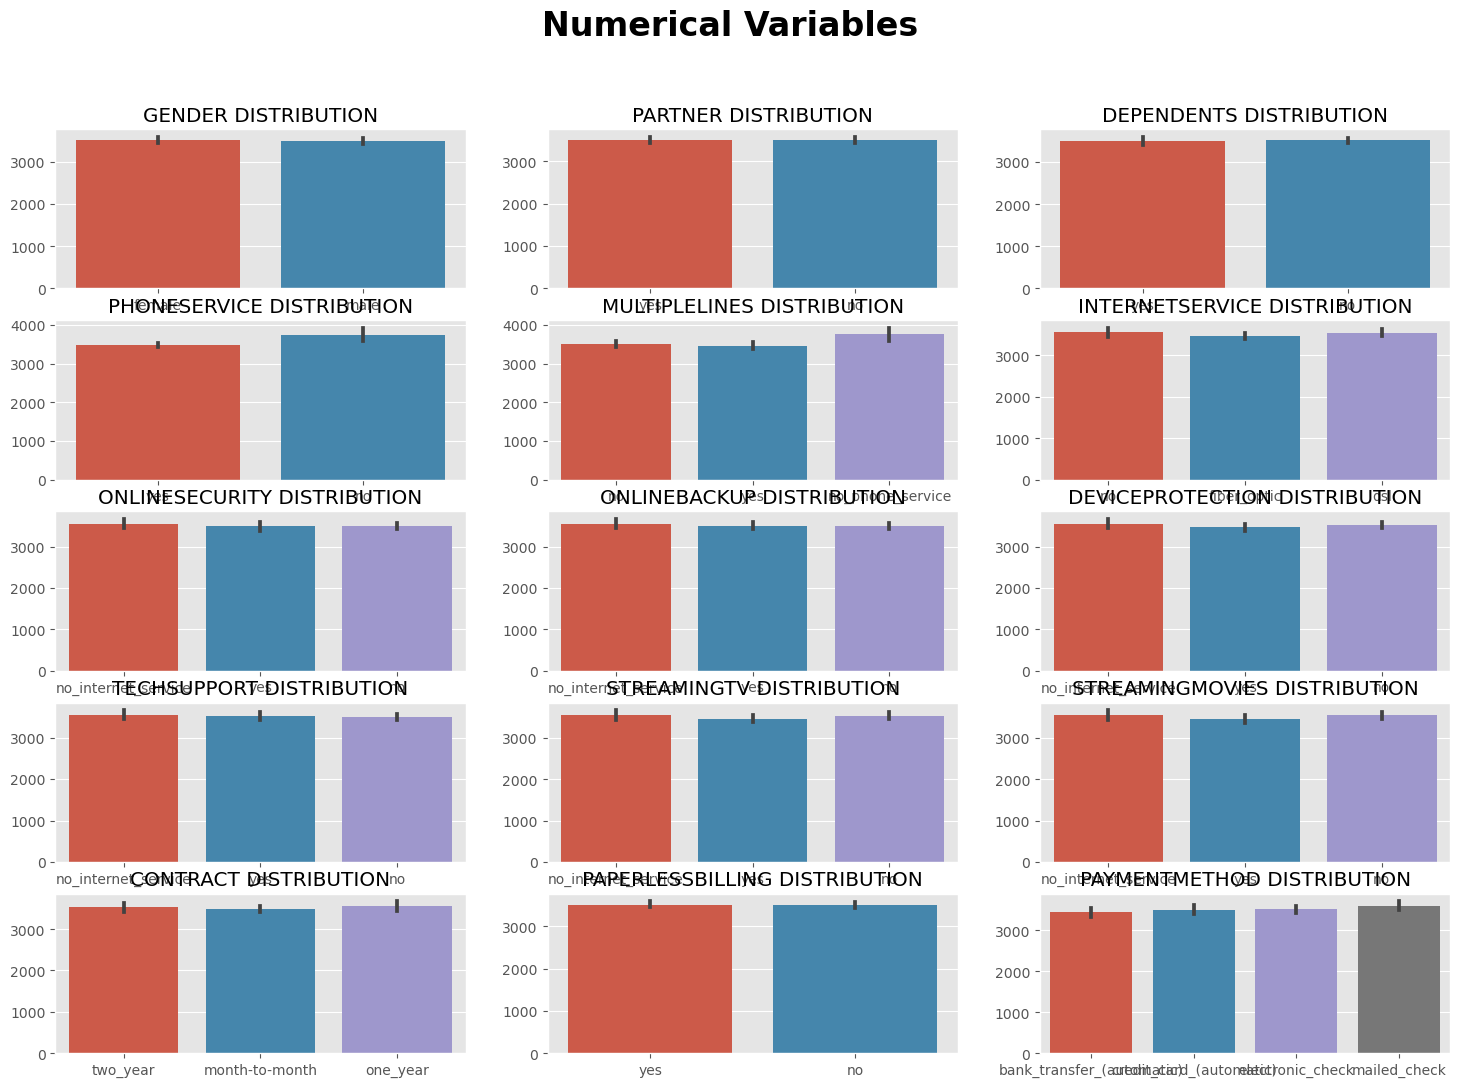

In [110]:
plt.style.use('ggplot')
fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(18,12))
ax = ax.flatten()
plt.suptitle('Numerical Variables', fontweight='bold', fontsize=24)

for idx, var in enumerate(categorical):
    # Distribution Plots
    sns.barplot(x=df_train_full[var].values, y=df_train_full[var].index, ax=ax[idx])
    ax[idx].set_title((var + ' distribution').upper())
    ax[idx].set_xlabel(None)

### Risk ratio

In [13]:


for col in categorical:
    df_group =df_train_full.groupby(col).churn.agg(['mean'])
    df_group['diff'] = df_group['mean'] - global_mean
    df_group['rate'] = df_group['mean'] / global_mean
    display(df_group)

,mean,diff,rate
gender,,,
female,0.271627,0.004854,1.018194
male,0.261947,-0.004826,0.981909


,mean,diff,rate
partner,,,
no,0.334711,0.067938,1.254664
yes,0.194505,-0.072268,0.729104


,mean,diff,rate
dependents,,,
no,0.315549,0.048776,1.182836
yes,0.153710,-0.113063,0.576183


,mean,diff,rate
phoneservice,,,
no,0.241636,-0.025137,0.905772
yes,0.269427,0.002654,1.009948


,mean,diff,rate
multiplelines,,,
no,0.252377,-0.014396,0.946038
no_phone_service,0.241636,-0.025137,0.905772
yes,0.289162,0.022389,1.083924


...

,mean,diff,rate
streamingtv,,,
no,0.333185,0.066412,1.248947
no_internet_service,0.072667,-0.194106,0.272393
yes,0.306132,0.039359,1.147536


,mean,diff,rate
streamingmovies,,,
no,0.331841,0.065067,1.243905
no_internet_service,0.072667,-0.194106,0.272393
yes,0.307763,0.040989,1.153649


,mean,diff,rate
contract,,,
month-to-month,0.426272,0.159499,1.597881
one_year,0.119390,-0.147383,0.447535
two_year,0.028211,-0.238562,0.105748


,mean,diff,rate
paperlessbilling,,,
no,0.164342,-0.102431,0.616036
yes,0.337126,0.070353,1.263717


,mean,diff,rate
paymentmethod,,,
bank_transfer_(automatic),0.163347,-0.103427,0.612305
credit_card_(automatic),0.160331,-0.106443,0.601000
electronic_check,0.458244,0.191471,1.717729
mailed_check,0.190623,-0.076151,0.714549


### Mutual Infformation

In [14]:
# Mutual Information
def calculate_mi(series):
    return mutual_info_score(series, df_train_full.churn)

df_mi = df_train_full[categorical].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='mi')
df_mi

,mi
contract,0.096535
onlinesecurity,0.066711
techsupport,0.062991
internetservice,0.059182
onlinebackup,0.047450
paymentmethod,0.045165
deviceprotection,0.044299
streamingtv,0.032284
streamingmovies,0.032216
paperlessbilling,0.019216


### Correlation Coefficient

In [15]:
df_train_full[numerical].corrwith(df_train_full.churn)

tenure           -0.353014
monthlycharges    0.203613
totalcharges     -0.196794
dtype: float64

## Feature Engineering

In [16]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')

# DictVectorizer
dv = DictVectorizer(sparse=False)
dv.fit(train_dict)

# 
X_train = dv.transform(train_dict)
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'streamingmovies=no',
       'streamingmovies=no_internet_service', 'streamingmovies

### Training the model

In [17]:
# Logistic Regression
model = LogisticRegression(solver='liblinear', random_state=12)
model.fit(X_train, y_train)

LogisticRegression(random_state=12, solver='liblinear')

In [18]:
# Preparing Validation set
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn = y_pred >= 0.5

# Accuracy
(y_val == churn).mean()

0.8048387096774193

In [19]:
# Model Intercept
print("Model Intercept: {}".format(model.intercept_[0]))
# Weights
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

Model Intercept: -0.13303937707671426


{'contract=month-to-month': 0.229,
 'contract=one_year': -0.087,
 'contract=two_year': -0.275,
 'dependents=no': 0.09,
 'dependents=yes': -0.223,
 'deviceprotection=no': 0.04,
 'deviceprotection=no_internet_service': -0.094,
 'deviceprotection=yes': -0.079,
 'gender=female': -0.014,
 'gender=male': -0.119,
 'internetservice=dsl': -0.281,
 'internetservice=fiber_optic': 0.242,
 'internetservice=no': -0.094,
 'monthlycharges': 0.006,
 'multiplelines=no': -0.251,
 'multiplelines=no_phone_service': 0.023,
 'multiplelines=yes': 0.095,
 'onlinebackup=no': 0.053,
 'onlinebackup=no_internet_service': -0.094,
 'onlinebackup=yes': -0.092,
 'onlinesecurity=no': 0.188,
 'onlinesecurity=no_internet_service': -0.094,
 'onlinesecurity=yes': -0.227,
 'paperlessbilling=no': -0.227,
 'paperlessbilling=yes': 0.094,
 'partner=no': -0.026,
 'partner=yes': -0.107,
 'paymentmethod=bank_transfer_(automatic)': -0.158,
 'paymentmethod=credit_card_(automatic)': -0.151,
 'paymentmethod=electronic_check': 0.343,
 